In [2]:
from IPython.display import Image, display
import operator
from typing import Annotated, Literal, TypedDict
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt

In [ ]:
class State(TypedDict):
    name: Annotated[list[str], operator.concat]

In [53]:
def a_node(state: State) -> State:
    print(f"a_node called {state['name']}")
    state["name"] = ["a"]
    return state

def b1_node(state: State) -> State:
    print(f"b1_node called {state['name']}")
    state["name"] = ["b1"]
    return state

def c1_node(state: State) -> State:
    print(f"c1_node called {state['name']}")
    state["name"] = ["c1"]
    return state

def d1_node(state: State) -> State:
    print(f"d1_node called {state['name']}")
    state["name"] = ["d1"]
    return state

def b2_node(state: State) -> State:
    print(f"b2_node called {state['name']}")
    state["name"] = ["b2"]
    return state

def c2_node(state: State) -> State:
    print(f"c2_node called {state['name']}")
    state["name"] = ["c2"]
    return state

def d2_node(state: State) -> State:
    print(f"d2_node called {state['name']}")
    state["name"] = ["d2"]
    return state    

In [54]:
builder = StateGraph(State)
builder.add_node("a", a_node)
builder.add_node("b1", b1_node)
builder.add_node("c1", c1_node)
builder.add_node("d1", d1_node)
builder.add_node("b2", b2_node)
builder.add_node("c2", c2_node)
builder.add_node("d2", d2_node)

builder.add_edge(START, "a")
builder.add_edge("a", "b1")
builder.add_edge("a", "c1")
builder.add_edge("a", "d1")
builder.add_edge("b1", "b2")
builder.add_edge("c1", "c2")
builder.add_edge("d1", "d2")
builder.add_edge("b2", END)
builder.add_edge("c2", END)
builder.add_edge("d2", END)

graph = builder.compile()

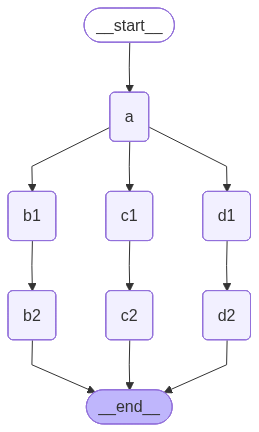

In [55]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [56]:
graph.invoke(State(name = ["start"]))

a_node called ['start']
b1_node called ['start', 'a']
c1_node called ['start', 'a']
d1_node called ['start', 'a']
b2_node called ['start', 'a', 'b1', 'c1', 'd1']
c2_node called ['start', 'a', 'b1', 'c1', 'd1']
d2_node called ['start', 'a', 'b1', 'c1', 'd1']


{'name': ['start', 'a', 'b1', 'c1', 'd1', 'b2', 'c2', 'd2']}